# Notebook 00 — Introduction, with **every bit of math worked out by hand**

Last time the words were there but the *numbers* were missing, so it stayed abstract.
This version fixes that. **Rule for this whole notebook:**

> Every formula is shown three ways:
> 1. **Plain words** — what it does and *why we want it*.
> 2. **A tiny worked example by hand** — real small numbers, every multiply and add written out.
> 3. **Code that re-computes the same thing** — so you can *see* the hand answer was right.

We keep the numbers tiny (2- and 3-element vectors) on purpose, so you can follow every
arithmetic step with a pen if you want. The shapes are exactly what the real model uses —
only the sizes are shrunk.

**How to read it:** run each code cell right after reading the markdown above it, and
check that the printed numbers match the hand calculation. That matching is the whole point.

## Part A — The one-paragraph big picture

A GPT is a machine that does exactly one thing: **given the text so far, guess the next word.**
To do that it turns words into lists of numbers (*vectors*), lets those vectors mix information
with each other (*attention*), pushes them through some multiply-and-add layers (*neural network*),
and finally turns the result back into a probability for every possible next word. Training =
nudging all those numbers until the guesses get good.

Every one of those steps is built from just **five** math operations. If you understand these
five, you understand the entire model. The rest of this notebook teaches them one at a time:

1. **Dot product** — measure how similar two vectors are (one number).
2. **Matrix multiply** — do many dot products at once (this *is* a neural-network layer).
3. **ReLU / nonlinearity** — bend straight lines so the model can learn curves.
4. **Softmax** — turn a list of arbitrary numbers into probabilities that add to 1.
5. **Gradient descent** — the rule that actually does the learning.

Let's go.

## B1 — Vectors: what a "list of numbers" means

A **vector** is just an ordered list of numbers, e.g. `[2, 1, 3]`.

Why we care: a computer cannot do math on the word `"cat"`. So we *represent* `"cat"` as a
vector like `[0.1, 0.9]`. Each number is called a **dimension** or **feature**. You can loosely
read the two numbers as, say, "how animal-like" and "how furry". The model invents these meanings
itself during training — we never assign them by hand.

A **matrix** is just a grid (a stack of vectors), e.g. a 3×2 matrix is 3 rows, each a 2-number vector.

That's the entire vocabulary we need. Run the cell to see them in code.

In [1]:
import torch
torch.manual_seed(0)

v = torch.tensor([2.0, 1.0, 3.0])          # a vector: 3 numbers
M = torch.tensor([[0.1, 0.9],              # a matrix: 3 rows x 2 columns
                  [0.8, 0.2],
                  [0.7, 0.3]])

print("vector v       :", v.tolist(), " shape", tuple(v.shape))
print("matrix M (3x2) :"); print(M)
print("M has shape", tuple(M.shape), "-> 3 rows, each a 2-number vector")
print("row 1 of M     :", M[1].tolist(), " (this could be the vector for one word)")

vector v       : [2.0, 1.0, 3.0]  shape (3,)
matrix M (3x2) :
tensor([[0.1000, 0.9000],
        [0.8000, 0.2000],
        [0.7000, 0.3000]])
M has shape (3, 2) -> 3 rows, each a 2-number vector
row 1 of M     : [0.800000011920929, 0.20000000298023224]  (this could be the vector for one word)


## B2 — The dot product: the most important operation in the whole model

**What it does:** takes two vectors of the same length, multiplies them position-by-position,
and adds everything up. The result is a **single number**.

**Formula (length 3):**  `a · b = a1*b1 + a2*b2 + a3*b3`

**Worked example by hand.** Let `a = [2, 1, 3]` and `b = [1, 0, 2]`:

```
a · b = (2 × 1) + (1 × 0) + (3 × 2)
      =   2     +   0      +   6
      =   8
```

**Why we care — the dot product measures similarity.** If two vectors *point the same way*,
their dot product is large and positive. If they point in opposite ways, it's negative. If
they're unrelated (perpendicular), it's near zero. This single fact is the engine of attention
later: a word decides "how much should I pay attention to that other word?" by taking the dot
product of their vectors.

Quick intuition check, all length-2:
```
[1, 0] · [1, 0] = 1*1 + 0*0 = 1     same direction  -> big
[1, 0] · [0, 1] = 1*0 + 0*1 = 0     perpendicular   -> zero
[1, 0] · [-1,0] = 1*-1+ 0*0 = -1    opposite        -> negative
```

In [2]:
import torch
a = torch.tensor([2.0, 1.0, 3.0])
b = torch.tensor([1.0, 0.0, 2.0])

# by hand we got 8 ; three equivalent ways to compute it:
print("element-wise products a*b :", (a*b).tolist(), " (multiply position by position)")
print("sum of those              :", (a*b).sum().item(), " <- this is the dot product")
print("torch.dot(a, b)           :", torch.dot(a, b).item())
print("a @ b  (the @ operator)   :", (a @ b).item())
print()
print("Similarity intuition:")
print(" [1,0].[1,0] =", torch.dot(torch.tensor([1.,0.]), torch.tensor([1.,0.])).item(), " (same way -> big)")
print(" [1,0].[0,1] =", torch.dot(torch.tensor([1.,0.]), torch.tensor([0.,1.])).item(), " (perpendicular -> 0)")
print(" [1,0].[-1,0]=", torch.dot(torch.tensor([1.,0.]), torch.tensor([-1.,0.])).item(), " (opposite -> negative)")

element-wise products a*b : [2.0, 0.0, 6.0]  (multiply position by position)
sum of those              : 8.0  <- this is the dot product
torch.dot(a, b)           : 8.0
a @ b  (the @ operator)   : 8.0

Similarity intuition:
 [1,0].[1,0] = 1.0  (same way -> big)
 [1,0].[0,1] = 0.0  (perpendicular -> 0)
 [1,0].[-1,0]= -1.0  (opposite -> negative)


## B3 — Matrix × vector = a neural-network layer (many dot products at once)

**Key realization:** a matrix-times-vector is just **one dot product per row** of the matrix.

**Worked example by hand.** Let
```
W = [ 1  2 ]        x = [ 2 ]
    [ 0  1 ]            [ 1 ]
    [ 3  1 ]
```
W is 3×2, x has 2 numbers. We dot **each row of W** with x:

```
row 0:  [1, 2] · [2, 1] = 1*2 + 2*1 = 2 + 2 = 4
row 1:  [0, 1] · [2, 1] = 0*2 + 1*1 = 0 + 1 = 1
row 2:  [3, 1] · [2, 1] = 3*2 + 1*1 = 6 + 1 = 7
```
So `W x = [4, 1, 7]`.

**Why we care:** this single operation took a 2-number input and produced a 3-number output.
That is *exactly* what a neural-network layer does — it mixes the inputs together in learned
amounts (the numbers inside W are the things training adjusts). The rule for shapes:

```
(rows × inner) times (inner) -> (rows)
( 3   ×   2  ) times (  2  ) -> ( 3  )
```
The inner sizes (the 2's) must match; they "cancel", and the output length is the number of rows.

In [3]:
import torch
W = torch.tensor([[1.0, 2.0],
                  [0.0, 1.0],
                  [3.0, 1.0]])     # 3 x 2
x = torch.tensor([2.0, 1.0])       # 2

print("W shape", tuple(W.shape), " x shape", tuple(x.shape))
print("W @ x =", (W @ x).tolist(), " (hand answer was [4, 1, 7])")
print()
# Show it really is one dot product per row:
for i in range(W.shape[0]):
    print(f" row {i}: {W[i].tolist()} . {x.tolist()} = {torch.dot(W[i], x).item()}")

W shape (3, 2)  x shape (2,)
W @ x = [4.0, 1.0, 7.0]  (hand answer was [4, 1, 7])

 row 0: [1.0, 2.0] . [2.0, 1.0] = 4.0
 row 1: [0.0, 1.0] . [2.0, 1.0] = 1.0
 row 2: [3.0, 1.0] . [2.0, 1.0] = 7.0


## B4 — The full linear layer: z = W x + b

Real layers add a **bias** vector `b` after the matrix multiply. The bias lets the layer shift
its output up or down independently of the input (like the `+c` in `y = m*x + c`).

**Full formula:**  `z = W x + b`

**Worked example.** Reusing `W x = [4, 1, 7]` from B3, with bias `b = [1, 1, 1]`:
```
z = [4, 1, 7] + [1, 1, 1] = [5, 2, 8]
```

The numbers inside `W` and `b` together are called the layer's **parameters** or **weights**.
A GPT is millions of these numbers. "Training the model" literally means "finding good values
for W and b in every layer." Everything else is plumbing.

In [4]:
import torch
W = torch.tensor([[1.,2.],[0.,1.],[3.,1.]])
x = torch.tensor([2., 1.])
b = torch.tensor([1., 1., 1.])

z = W @ x + b
print("z = W x + b =", z.tolist(), " (hand answer was [5, 2, 8])")

# This is exactly what torch.nn.Linear does internally:
layer = torch.nn.Linear(in_features=2, out_features=3, bias=True)
with torch.no_grad():            # manually set its weights to our W and b to prove it
    layer.weight.copy_(W)
    layer.bias.copy_(b)
print("nn.Linear gives           :", layer(x).tolist(), " (identical)")
print("layer parameters W, b are what training adjusts.")

z = W x + b = [5.0, 2.0, 8.0]  (hand answer was [5, 2, 8])
nn.Linear gives           : [5.0, 2.0, 8.0]  (identical)
layer parameters W, b are what training adjusts.


## B5 — ReLU and *why* we need a nonlinearity

**ReLU** ("rectified linear unit") is the simplest nonlinearity: it keeps positive numbers and
turns negatives into 0.

**Formula:**  `ReLU(z) = max(0, z)`, applied to each number separately.

**Worked example:**
```
ReLU([-2, 3, 0, 5]) = [0, 3, 0, 5]
       ^               ^
   -2 -> 0          3 stays 3
```

**Why we care — without it, depth is pointless.** Suppose we stack two linear layers with *no*
nonlinearity between them: `output = W2 (W1 x)`. By the rules of matrix multiply,
`W2 (W1 x) = (W2 W1) x`, and `W2 W1` is just *one* matrix. So a hundred stacked linear layers
collapse into a single linear layer — they can only ever draw straight lines.

**Worked collapse example.** Let
```
W1 = [1 2]      W2 = [1 0]
     [3 4]           [1 1]
```
Then `W2 W1 = [1*1+0*3, 1*2+0*4] = [1, 2]`
            `[1*1+1*3, 1*2+1*4]   [4, 6]`

So two layers `= [[1,2],[4,6]]` — a single matrix. Putting `ReLU` between them breaks this
collapse, and *that* is what lets deep networks learn curves, not just straight lines.

In [5]:
import torch
z = torch.tensor([-2.0, 3.0, 0.0, 5.0])
print("ReLU([-2,3,0,5]) =", torch.relu(z).tolist(), " (hand answer [0,3,0,5])")
print()

W1 = torch.tensor([[1.,2.],[3.,4.]])
W2 = torch.tensor([[1.,0.],[1.,1.]])
x  = torch.tensor([1.0, 1.0])

collapsed = W2 @ W1
print("W2 @ W1 =", collapsed.tolist(), " (the two linear layers ARE just this one matrix)")
print("W2 @ (W1 @ x)      =", (W2 @ (W1 @ x)).tolist())
print("(W2 @ W1) @ x      =", (collapsed @ x).tolist(), " <- identical: depth gained NOTHING")
print()
print("Now insert ReLU between them:")
print("W2 @ ReLU(W1 @ x)  =", (W2 @ torch.relu(W1 @ x)).tolist(), " <- different! the nonlinearity matters")

ReLU([-2,3,0,5]) = [0.0, 3.0, 0.0, 5.0]  (hand answer [0,3,0,5])

W2 @ W1 = [[1.0, 2.0], [4.0, 6.0]]  (the two linear layers ARE just this one matrix)
W2 @ (W1 @ x)      = [3.0, 10.0]
(W2 @ W1) @ x      = [3.0, 10.0]  <- identical: depth gained NOTHING

Now insert ReLU between them:
W2 @ ReLU(W1 @ x)  = [3.0, 10.0]  <- different! the nonlinearity matters


## B6 — Softmax: turning raw scores into probabilities

The model's final output is a list of raw scores (called **logits**), one per possible next word.
Scores like `[2, 1, 0]` are not probabilities — they don't add to 1 and could even be negative.
**Softmax** fixes that.

**Formula:**  `softmax(z)_i = exp(z_i) / sum_j exp(z_j)`

In words: raise `e ≈ 2.718` to the power of each score (this makes everything positive and
exaggerates differences), then divide each by the total so they sum to 1.

**Worked example by hand.** Scores `z = [2, 1, 0]`:
```
step 1 - exponentiate:
   exp(2) = 7.389
   exp(1) = 2.718
   exp(0) = 1.000
step 2 - sum them:
   7.389 + 2.718 + 1.000 = 11.107
step 3 - divide each by the sum:
   7.389 / 11.107 = 0.665
   2.718 / 11.107 = 0.245
   1.000 / 11.107 = 0.090
```
Result: `[0.665, 0.245, 0.090]`. Notice they're all positive and add to 1.0 — a valid probability
distribution. The biggest score (2) got the biggest probability (66.5%). That's softmax.

In [6]:
import torch, math
z = torch.tensor([2.0, 1.0, 0.0])

# do it the long way, exactly as the hand calc:
exps = torch.exp(z)
print("exp of each score :", [round(e,3) for e in exps.tolist()], " (hand: 7.389, 2.718, 1.000)")
print("sum of exps       :", round(exps.sum().item(), 3), " (hand: 11.107)")
manual = exps / exps.sum()
print("manual softmax    :", [round(p,3) for p in manual.tolist()], " (hand: 0.665, 0.245, 0.090)")

# the built-in, which we'll use everywhere:
print("torch.softmax     :", [round(p,3) for p in torch.softmax(z, dim=0).tolist()])
print("they sum to       :", round(torch.softmax(z, dim=0).sum().item(), 6))

exp of each score : [7.389, 2.718, 1.0]  (hand: 7.389, 2.718, 1.000)
sum of exps       : 11.107  (hand: 11.107)
manual softmax    : [0.665, 0.245, 0.09]  (hand: 0.665, 0.245, 0.090)
torch.softmax     : [0.665, 0.245, 0.09]
they sum to       : 1.0


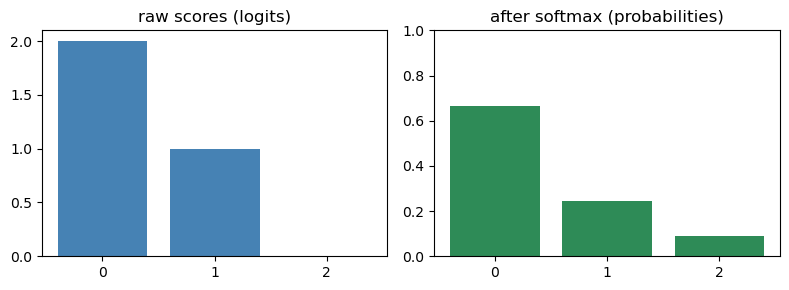

probabilities: [0.665, 0.245, 0.09]  sum = 1.0


In [7]:
# Picture it: softmax keeps the order but squashes scores into 0..1 that sum to 1
import matplotlib.pyplot as plt, torch
z = torch.tensor([2.0, 1.0, 0.0])
p = torch.softmax(z, dim=0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.bar(range(3), z.tolist(), color="steelblue"); ax1.set_title("raw scores (logits)"); ax1.set_xticks(range(3))
ax2.bar(range(3), p.tolist(), color="seagreen"); ax2.set_title("after softmax (probabilities)"); ax2.set_xticks(range(3))
ax2.set_ylim(0, 1)
plt.tight_layout(); plt.show()
print("probabilities:", [round(x,3) for x in p.tolist()], " sum =", round(p.sum().item(),3))

## B7 — Embeddings: looking up a word's vector

Now we connect words to numbers. An **embedding table** is just a matrix with **one row per word**
in the vocabulary. To embed a word, we look up its row. That's it — embedding is a *lookup*, not
a multiplication.

**Worked example.** Tiny vocabulary of 3 words with 2-dimensional vectors:
```
            dim0  dim1
"cat" (id 0) [0.1, 0.9]
"sat" (id 1) [0.8, 0.2]
"mat" (id 2) [0.7, 0.3]
```
The sentence `"cat mat sat"` is token ids `[0, 2, 1]`. Embedding it = grab rows 0, 2, 1:
```
id 0 -> [0.1, 0.9]
id 2 -> [0.7, 0.3]
id 1 -> [0.8, 0.2]
```
Output shape: 3 tokens × 2 numbers. These row-vectors *start* random and are **learned** during
training, so that words used in similar ways end up with similar vectors (close by dot product).

In [8]:
import torch
table = torch.tensor([[0.1, 0.9],    # id 0 "cat"
                      [0.8, 0.2],    # id 1 "sat"
                      [0.7, 0.3]])   # id 2 "mat"
tokens = torch.tensor([0, 2, 1])     # "cat mat sat"

embedded = table[tokens]             # fancy indexing = row lookup
print("token ids        :", tokens.tolist())
print("embedded (3 x 2) :"); print(embedded)
print("shape            :", tuple(embedded.shape), " -> 3 tokens, each a 2-number vector")
print()
# nn.Embedding is literally this lookup wrapped in a module:
emb = torch.nn.Embedding(num_embeddings=3, embedding_dim=2)
with torch.no_grad():
    emb.weight.copy_(table)
print("nn.Embedding gives same:"); print(emb(tokens))

token ids        : [0, 2, 1]
embedded (3 x 2) :
tensor([[0.1000, 0.9000],
        [0.7000, 0.3000],
        [0.8000, 0.2000]])
shape            : (3, 2)  -> 3 tokens, each a 2-number vector

nn.Embedding gives same:
tensor([[0.1000, 0.9000],
        [0.7000, 0.3000],
        [0.8000, 0.2000]], grad_fn=<EmbeddingBackward0>)


## B8 — Positional encoding: telling the model the *order*

Attention (next section) treats its inputs as an unordered bag — by itself it can't tell
`"dog bites man"` from `"man bites dog"`. So we **add** a second vector to each token that encodes
*where* it sits in the sentence.

**Worked example.** Take the embedded sentence from B7 and add a position vector to each row
(position 0, 1, 2 get different vectors):
```
                embedding        + position      = result
pos 0 ("cat") [0.1, 0.9]  +  [0.0, 0.0]  =  [0.1, 0.9]
pos 1 ("mat") [0.7, 0.3]  +  [0.5, 0.5]  =  [1.2, 0.8]
pos 2 ("sat") [0.8, 0.2]  +  [1.0, 1.0]  =  [1.8, 1.2]
```
Same shape as before (3 × 2) — we didn't add new numbers, we *mixed in* position information.
Now two identical words in different positions get different vectors, so the model can use order.

In [9]:
import torch
embedded = torch.tensor([[0.1, 0.9],
                         [0.7, 0.3],
                         [0.8, 0.2]])
positions = torch.tensor([[0.0, 0.0],
                          [0.5, 0.5],
                          [1.0, 1.0]])
x = embedded + positions
print("embedding + position = order-aware input:")
print(x)
print("hand answer: [0.1,0.9], [1.2,0.8], [1.8,1.2]")

embedding + position = order-aware input:
tensor([[0.1000, 0.9000],
        [1.2000, 0.8000],
        [1.8000, 1.2000]])
hand answer: [0.1,0.9], [1.2,0.8], [1.8,1.2]


## B9 — Self-attention, fully worked out (the heart of GPT)

This is the part everyone finds hard, so we do **every number by hand**. The idea:
each token looks at all tokens (including itself), decides how relevant each one is
(using **dot-product similarity** from B2!), and builds a new version of itself as a
weighted blend of everyone's information.

Three roles, all made from the input `X` by multiplying with learned matrices:
- **Query (Q)** — "what am I looking for?"
- **Key (K)** — "what do I offer?"
- **Value (V)** — "what information do I pass on if chosen?"

`Q = X Wq`,  `K = X Wk`,  `V = X Wv`.

To keep the arithmetic clean we use the **simplest possible** weight matrices: the identity
(`Wq = Wk = Wv = I`), so `Q = K = V = X`. (In a real model these are learned and different;
the *procedure* is identical.)

**Our input:** 3 tokens, 2 dimensions:
```
X = [1, 0]   token 0
    [0, 1]   token 1
    [1, 1]   token 2
```

### Step 1 — scores = how much each token matches each other token (Q · K for every pair)

Dot every token's Query with every token's Key. Since Q=K=X, that's every row dotted with
every row:
```
              K0=[1,0]   K1=[0,1]   K2=[1,1]
Q0=[1,0]  ->    1          0          1
Q1=[0,1]  ->    0          1          1
Q2=[1,1]  ->    1          1          2
```
(e.g. Q2·K2 = 1*1 + 1*1 = 2). This 3×3 grid says how strongly each token "wants" each other token.

### Step 2 — scale by sqrt(dimension)

We divide by `sqrt(d) = sqrt(2) ≈ 1.414`. (Reason: with bigger dimensions the dot products grow
large, which makes softmax too "spiky"; dividing keeps it well-behaved.) Scores become:
```
[0.707, 0.000, 0.707]
[0.000, 0.707, 0.707]
[0.707, 0.707, 1.414]
```

### Step 3 — softmax each row (turn scores into weights that sum to 1)

Apply B6's softmax to each row independently. Row 0, `[0.707, 0, 0.707]`:
```
exp: 2.028, 1.000, 2.028   sum = 5.056
->   0.401, 0.198, 0.401   (token 0 splits its attention)
```
All three rows:
```
row 0: [0.401, 0.198, 0.401]
row 1: [0.198, 0.401, 0.401]
row 2: [0.248, 0.248, 0.504]   (token 2 attends mostly to itself)
```

### Step 4 — output = weighted sum of Values (weights @ V), V = X

Each token's new vector = its attention weights times the value rows. Token 0:
```
0.401*[1,0] + 0.198*[0,1] + 0.401*[1,1]
= [0.401+0+0.401 , 0+0.198+0.401]
= [0.802, 0.599]
```
All three outputs:
```
token 0 -> [0.802, 0.599]
token 1 -> [0.599, 0.802]
token 2 -> [0.752, 0.752]
```
**That's self-attention.** Every output token is now a blend of information from the tokens it
chose to attend to. The code below reproduces all four steps and matches these hand numbers.

In [10]:
import torch
X = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 1.0]])      # 3 tokens, 2 dims
d = X.shape[1]                      # = 2

# Wq=Wk=Wv=I  ->  Q=K=V=X
Q = K = V = X

# Step 1: scores = Q . K^T  (every query row dotted with every key row)
scores = Q @ K.T
print("Step 1  scores (Q@K^T):"); print(scores)
print("   hand: [[1,0,1],[0,1,1],[1,1,2]]\n")

# Step 2: scale by sqrt(d)
scaled = scores / (d ** 0.5)
print("Step 2  scaled by sqrt(2)=%.3f:" % (d**0.5)); print(scaled.round(decimals=3), "\n")

# Step 3: softmax each row
weights = torch.softmax(scaled, dim=-1)
print("Step 3  attention weights (each row sums to 1):"); print(weights.round(decimals=3))
print("   row sums:", weights.sum(dim=-1).tolist(), "\n")

# Step 4: output = weights @ V
out = weights @ V
print("Step 4  output = weights @ V:"); print(out.round(decimals=3))
print("   hand: [[0.802,0.599],[0.599,0.802],[0.752,0.752]]")

Step 1  scores (Q@K^T):
tensor([[1., 0., 1.],
        [0., 1., 1.],
        [1., 1., 2.]])
   hand: [[1,0,1],[0,1,1],[1,1,2]]

Step 2  scaled by sqrt(2)=1.414:
tensor([[0.7070, 0.0000, 0.7070],
        [0.0000, 0.7070, 0.7070],
        [0.7070, 0.7070, 1.4140]]) 

Step 3  attention weights (each row sums to 1):
tensor([[0.4010, 0.1980, 0.4010],
        [0.1980, 0.4010, 0.4010],
        [0.2480, 0.2480, 0.5030]])
   row sums: [1.0, 1.0, 1.0] 

Step 4  output = weights @ V:
tensor([[0.8020, 0.5990],
        [0.5990, 0.8020],
        [0.7520, 0.7520]])
   hand: [[0.802,0.599],[0.599,0.802],[0.752,0.752]]


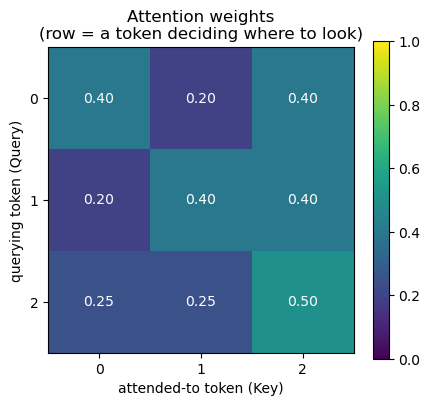

In [11]:
# Visualize who-attends-to-whom (this heatmap IS the model's reasoning)
import matplotlib.pyplot as plt, torch
X = torch.tensor([[1.,0.],[0.,1.],[1.,1.]]); d = 2
weights = torch.softmax((X @ X.T)/d**0.5, dim=-1)
fig, ax = plt.subplots(figsize=(4.5,4))
im = ax.imshow(weights, cmap="viridis", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{weights[i,j]:.2f}", ha="center", va="center", color="white")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xlabel("attended-to token (Key)"); ax.set_ylabel("querying token (Query)")
ax.set_title("Attention weights\n(row = a token deciding where to look)")
fig.colorbar(im); plt.tight_layout(); plt.show()

## B9b — Causal masking: why GPT can only look *backwards*

GPT predicts the next word, so when processing position `i` it must **not** be allowed to peek at
words that come *after* `i` (that would be cheating — looking at the answer). We enforce this by
setting all "future" scores to **−infinity** *before* the softmax. Since `exp(−inf) = 0`, those
positions get exactly 0 weight.

**Worked example** on our scaled scores. We blank out everything above the diagonal:
```
before mask:                 after mask (-inf above diagonal):
[0.707, 0.000, 0.707]        [0.707,  -inf,  -inf ]
[0.000, 0.707, 0.707]   ->   [0.000, 0.707,  -inf ]
[0.707, 0.707, 1.414]        [0.707, 0.707, 1.414 ]
```
Now softmax each row. Row 0 can only see itself, so it must put **100%** weight on token 0:
```
row 0: softmax([0.707, -inf, -inf]) = [1.000, 0.000, 0.000]
row 1: softmax([0.000, 0.707, -inf]) = [0.330, 0.670, 0.000]
row 2: softmax([0.707, 0.707, 1.414]) = [0.248, 0.248, 0.504]   (unchanged: sees all)
```
This lower-triangular pattern is *the* signature of a GPT. Notebook 04 builds it for real.

In [12]:
import torch
X = torch.tensor([[1.,0.],[0.,1.],[1.,1.]]); d = 2
scaled = (X @ X.T) / d**0.5

mask = torch.tril(torch.ones(3, 3))            # 1 on/below diagonal, 0 above
print("mask (1=allowed, 0=future/forbidden):"); print(mask)

masked = scaled.masked_fill(mask == 0, float("-inf"))
print("\nscaled scores after masking future to -inf:"); print(masked.round(decimals=3))

weights = torch.softmax(masked, dim=-1)
print("\ncausal attention weights (note the lower-triangular shape):")
print(weights.round(decimals=3))
print("row 0 puts 100% on itself; nobody attends to the future.")

mask (1=allowed, 0=future/forbidden):
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

scaled scores after masking future to -inf:
tensor([[0.7070,   -inf,   -inf],
        [0.0000, 0.7070,   -inf],
        [0.7070, 0.7070, 1.4140]])

causal attention weights (note the lower-triangular shape):
tensor([[1.0000, 0.0000, 0.0000],
        [0.3300, 0.6700, 0.0000],
        [0.2480, 0.2480, 0.5030]])
row 0 puts 100% on itself; nobody attends to the future.


## B10 — From the model's output to an actual prediction

After the transformer layers, each token's vector is multiplied by a final matrix (the
**language-model head**) to produce one score per vocabulary word — the **logits**. Softmax
turns those into next-word probabilities, and we pick from them.

**Worked example.** Suppose after all the layers, the last token's logits over our 3-word vocab
`["cat","sat","mat"]` are `[2.0, 1.0, 0.0]`. We already softmaxed these in B6:
```
softmax([2,1,0]) = [0.665, 0.245, 0.090]
                     cat     sat     mat
```
The model predicts **"cat"** (66.5%) as the most likely next word. "Greedy decoding" = always
take the argmax; other strategies (temperature, top-k, top-p) sample more creatively — that's
Notebook 10.

In [13]:
import torch
vocab = ["cat", "sat", "mat"]
logits = torch.tensor([2.0, 1.0, 0.0])
probs = torch.softmax(logits, dim=0)

for w, p in zip(vocab, probs.tolist()):
    print(f"  P(next = {w!r}) = {p:.3f}")
print("\ngreedy choice (argmax):", vocab[torch.argmax(probs).item()])

  P(next = 'cat') = 0.665
  P(next = 'sat') = 0.245
  P(next = 'mat') = 0.090

greedy choice (argmax): cat


## B11 — Cross-entropy loss: measuring *how wrong* a guess is

Training needs a single number saying "how bad was that prediction?" For next-word prediction we
use **cross-entropy loss**, which has a beautifully simple form: it's just the negative log of the
probability the model gave to the *correct* word.

**Formula:**  `loss = -ln( p[correct word] )`

**Why this shape?** We want loss = 0 when the model is certain and right, and huge when it's
confidently wrong. `-ln(p)` does exactly that:
```
p[correct] = 1.00  ->  -ln(1.00) = 0.00   perfect, no penalty
p[correct] = 0.665 ->  -ln(0.665)= 0.408   pretty good
p[correct] = 0.090 ->  -ln(0.090)= 2.408   bad, big penalty
p[correct] -> 0     ->  -ln(0)   -> infinity   confidently wrong = catastrophic
```

**Worked example.** From B10 the model said `[0.665, 0.245, 0.090]` for `["cat","sat","mat"]`.
- If the true next word was **"cat"** (id 0): `loss = -ln(0.665) = 0.408` (low — good guess).
- If the true next word was **"mat"** (id 2): `loss = -ln(0.090) = 2.408` (high — bad guess).

Training adjusts all the weights to push the probability of the correct word **up**, which pushes
this loss **down**. That's the entire objective.

In [14]:
import torch, math
probs = torch.tensor([0.665, 0.245, 0.090])   # from B10
print("if correct word is 'cat' (id 0): loss = -ln(%.3f) = %.3f" % (probs[0], -math.log(probs[0])))
print("if correct word is 'mat' (id 2): loss = -ln(%.3f) = %.3f" % (probs[2], -math.log(probs[2])))
print()

# PyTorch's cross_entropy takes raw LOGITS (it does softmax + (-ln) for you):
logits = torch.tensor([[2.0, 1.0, 0.0]])      # batch of 1
target_cat = torch.tensor([0])
target_mat = torch.tensor([2])
print("F.cross_entropy, target 'cat':", round(torch.nn.functional.cross_entropy(logits, target_cat).item(), 3))
print("F.cross_entropy, target 'mat':", round(torch.nn.functional.cross_entropy(logits, target_mat).item(), 3))
print("(matches the hand answers 0.408 and 2.408)")

if correct word is 'cat' (id 0): loss = -ln(0.665) = 0.408
if correct word is 'mat' (id 2): loss = -ln(0.090) = 2.408

F.cross_entropy, target 'cat': 0.408
F.cross_entropy, target 'mat': 2.408
(matches the hand answers 0.408 and 2.408)


## B12 — Gradient descent: how the numbers actually learn

We have a loss telling us how wrong we are. Now: how do we change the weights to reduce it?
**Gradient descent.** The *gradient* is the slope of the loss with respect to a weight — it points
in the direction that *increases* loss, so we step the **opposite** way.

**Rule:**  `new_w = old_w - learning_rate × gradient`

**Worked example on the simplest possible loss.** Pretend we have one weight `w` and the loss is
`L(w) = (w - 3)²` (so the best value is obviously `w = 3`, where loss = 0). The slope is
`dL/dw = 2(w - 3)` (basic calculus). Start at `w = 0`, learning rate `0.1`:
```
step 1:  w=0.00   grad=2(0.00-3)=-6.00   w <- 0.00 - 0.1*(-6.00) = 0.60
step 2:  w=0.60   grad=2(0.60-3)=-4.80   w <- 0.60 - 0.1*(-4.80) = 1.08
step 3:  w=1.08   grad=2(1.08-3)=-3.84   w <- 1.08 - 0.1*(-3.84) = 1.46
 ...
```
Each step the loss `(w-3)²` shrinks and `w` crawls toward 3. A real GPT does this same step,
just for *millions* of weights at once, with the gradients computed automatically by
**backpropagation** (PyTorch's `loss.backward()`). We'll see backprop in detail in Notebook 03.

In [15]:
# Run gradient descent by hand on L(w) = (w-3)^2
w, lr = 0.0, 0.1
print(f"{'step':>4} {'w':>8} {'loss':>8} {'grad':>8}")
history = []
for step in range(1, 26):
    loss = (w - 3)**2
    grad = 2*(w - 3)
    history.append((step, w, loss))
    if step <= 5 or step % 5 == 0:
        print(f"{step:>4} {w:>8.3f} {loss:>8.3f} {grad:>8.3f}")
    w = w - lr*grad
print(f"\nafter 25 steps w = {w:.3f}  (true best is 3.000) -- it learned!")

step        w     loss     grad
   1    0.000    9.000   -6.000
   2    0.600    5.760   -4.800
   3    1.080    3.686   -3.840
   4    1.464    2.359   -3.072
   5    1.771    1.510   -2.458
  10    2.597    0.162   -0.805
  15    2.868    0.017   -0.264
  20    2.957    0.002   -0.086
  25    2.986    0.000   -0.028

after 25 steps w = 2.989  (true best is 3.000) -- it learned!


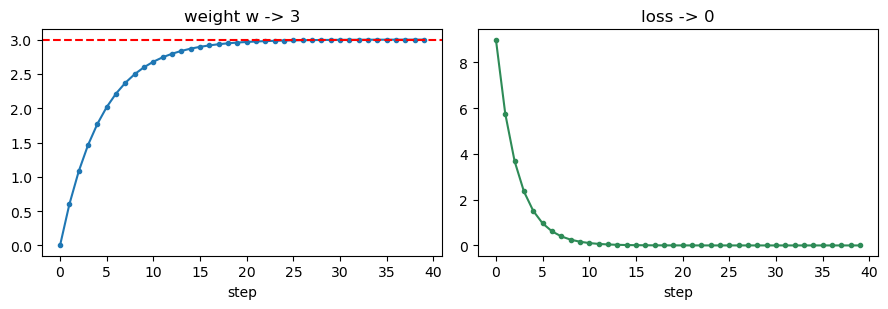

In [16]:
# Watch it converge
import matplotlib.pyplot as plt
w, lr, ws, losses = 0.0, 0.1, [], []
for _ in range(40):
    ws.append(w); losses.append((w-3)**2)
    w = w - lr*2*(w-3)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
a1.plot(ws, marker="o", ms=3); a1.axhline(3, ls="--", c="r"); a1.set_title("weight w -> 3"); a1.set_xlabel("step")
a2.plot(losses, marker="o", ms=3, c="seagreen"); a2.set_title("loss -> 0"); a2.set_xlabel("step")
plt.tight_layout(); plt.show()

## B13 — All five operations, one tiny end-to-end forward pass

Let's chain everything: embed a 2-token sentence, add positions, run one attention step, project
to vocab logits, softmax to probabilities, and read off the prediction. Tiny numbers throughout
so you can still trace shapes.

In [17]:
import torch
torch.manual_seed(1)

vocab = ["cat", "sat", "mat", "ran"]          # V = 4 words
V, C = len(vocab), 2                          # C = embedding dim

emb_table = torch.tensor([[0.1,0.9],[0.8,0.2],[0.7,0.3],[0.2,0.6]])  # (V, C)
pos_table = torch.tensor([[0.0,0.0],[0.5,0.5]])                       # (T=2, C)
lm_head   = torch.randn(C, V)                                        # (C, V)

sentence = torch.tensor([0, 2])               # "cat mat" -> T = 2
print("1. tokens         :", sentence.tolist(), "(\"cat mat\")")

x = emb_table[sentence]                       # (T, C)
print("2. embeddings     :", x.shape, "->", x.tolist())

x = x + pos_table                             # add order
print("3. + positions    :", x.tolist())

scores = (x @ x.T) / C**0.5                   # self-attention (Wq=Wk=Wv=I)
w = torch.softmax(scores, dim=-1)
x = w @ x
print("4. after attention:", x.round(decimals=3).tolist())

logits = x @ lm_head                          # (T, V) one score per word, per position
print("5. logits  (T,V)  :", logits.shape)

probs = torch.softmax(logits[-1], dim=-1)     # prediction comes from the LAST token
print("6. P(next word) after \"cat mat\":")
for word, p in zip(vocab, probs.tolist()):
    print(f"      {word:>4}: {p:.3f}")
print("   prediction:", vocab[torch.argmax(probs).item()], "(untrained, so it's basically random -- training fixes that)")

1. tokens         : [0, 2] ("cat mat")
2. embeddings     : torch.Size([2, 2]) -> [[0.10000000149011612, 0.8999999761581421], [0.699999988079071, 0.30000001192092896]]
3. + positions    : [[0.10000000149011612, 0.8999999761581421], [1.2000000476837158, 0.800000011920929]]
4. after attention: [[0.6539999842643738, 0.8500000238418579], [0.8769999742507935, 0.8289999961853027]]
5. logits  (T,V)  : torch.Size([2, 4])
6. P(next word) after "cat mat":
       cat: 0.246
       sat: 0.220
       mat: 0.060
       ran: 0.474
   prediction: ran (untrained, so it's basically random -- training fixes that)


## Recap — the whole model in one table

| Step | Operation | Math | Shape change |
|------|-----------|------|--------------|
| Tokenize | text → ids | (lookup) | text → `(T)` |
| Embed | id → vector | row lookup (B7) | `(T)` → `(T, C)` |
| Position | add order | vector add (B8) | `(T, C)` → `(T, C)` |
| Attention | mix tokens | dot products + softmax + weighted sum (B9) | `(T, C)` → `(T, C)` |
| Feed-forward | per-token compute | `W x + b`, ReLU (B4, B5) | `(T, C)` → `(T, C)` |
| LM head | vector → scores | matrix multiply (B3) | `(T, C)` → `(T, V)` |
| Softmax | scores → probs | softmax (B6) | `(T, V)` → `(T, V)` |
| Loss | measure error | `-ln(p_correct)` (B11) | → one number |
| Learn | improve weights | gradient descent (B12) | adjusts all W, b |

Every box is one of the five operations from Part A. There is no extra magic — a GPT is these
pieces, stacked deep and trained on a lot of text.

## Common mistakes
1. **Confusing the dot product (→ 1 number) with element-wise multiply (→ a vector).** Dot product *sums* afterward.
2. **Forgetting softmax needs ALL the scores** — you can't softmax one number; it's relative to the others.
3. **Reading attention weights backwards.** Row = the token *doing* the looking; column = the token *being* looked at.
4. **Thinking embeddings are computed.** They're *looked up* — a row grab, then *learned* over training.
5. **Dropping the nonlinearity** (B5) — without it, depth is wasted.

## Exercises (do them in new code cells)
1. Compute `[3, -1, 2] · [1, 4, 0]` by hand, then verify with `torch.dot`.
2. Multiply `W=[[2,0],[1,3]]` by `x=[4,1]` by hand (two dot products), then check with `@`.
3. Softmax `[0, 0, 0]` by hand. What do you get, and why does it make sense?
4. In B9, change `X[2]` to `[5, 5]` and re-run. Which token does token 2 now attend to most? Why?
5. For the loss `L(w)=(w-3)²`, redo B12 with learning rate `1.0`. Does it still converge? Try `0.01`. What does the learning rate control?

---

**You now have all five core operations with worked numbers.** Next:
[01_Tokenizer.ipynb](01_Tokenizer.ipynb) — we build the very first box of the table (text → token ids) from scratch.